<a href="https://colab.research.google.com/github/fioremartiro/Machine-Learning/blob/main/Supervised%20Learning/Classification%20Examples/1.%20logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 0. Import dependencies

In [31]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Loading raw object (Bunch)
cancer = load_breast_cancer()

# Creating structured table
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
# print (df.head())

### 1. Creating variables and data

In [32]:
X = df.drop(columns=['target'], axis=1)
Y = df['target']

### 2. Splitting the data - training and test

In [33]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
# print(X.shape, X_train.shape, X_test.shape)

### 3. Creating instance of the logistic regression class and fit the model into training

In [34]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train, Y_train)

LogisticRegression(max_iter=10000)

### 4. Actual predictions on test data

In [35]:
y_pred = model.predict(X_test)
print(y_pred)

[1 1 1 0 0 0 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1
 1 1 1 0 0 1 1 0 1 1 1 0 0 1 0 0 1 1 0 1 1 1 1 1 0 1 0 0 1 0 0 0 1 0 0 1 0
 1 0 1 1 1 0 0 0 0 1 1 0 1 1 1 0 1 1 1 0 0 1 0 0 1 1 1 0 0 0 1 1 1 1 1 1 0
 0 1 0]


### 5. Evaluate performance by calculating accuracy score

In [36]:
accuracy = accuracy_score(Y_test, y_pred)
print(accuracy)

0.9298245614035088


### 6. Plotting the data for visual representation

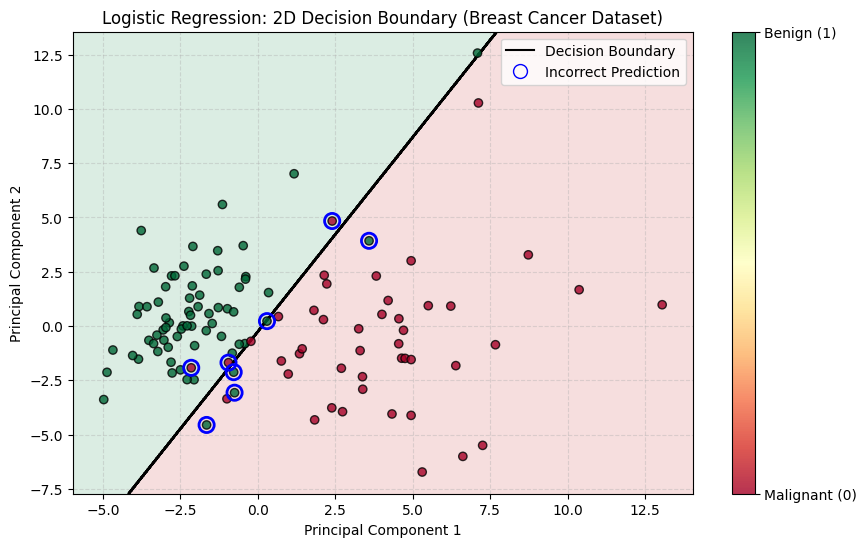

In [38]:
# 1. Scale and reduce dimensions via PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X_scaled)

# 2. Split using the same random state
X_train_2D, X_test_2D, Y_train_2D, Y_test_2D = train_test_split(X_2D, Y, test_size=0.2, random_state=2)

# 3. Train the visualization model
viz_model = LogisticRegression(max_iter=10000)
viz_model.fit(X_train_2D, Y_train_2D)

plt.figure(figsize=(10, 6))

# --- NEW: Code to draw the decision boundary line and background zones ---
# Create a grid covering the min and max space of our components
x_min, x_max = X_test_2D[:, 0].min() - 1, X_test_2D[:, 0].max() + 1
y_min, y_max = X_test_2D[:, 1].min() - 1, X_test_2D[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Predict values for the entire grid to draw the boundary line
Z = viz_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Paint the background decision regions (light green and light red)
plt.contourf(xx, yy, Z, alpha=0.15, cmap='RdYlGn')
# Draw the explicit solid line where the decision flips (the frontier)
plt.contour(xx, yy, Z, colors='black', linewidths=1.5, linestyles='solid')
# -------------------------------------------------------------------------

# 4. Plot test data points colored by true class
scatter = plt.scatter(X_test_2D[:, 0], X_test_2D[:, 1], c=Y_test_2D, cmap='RdYlGn', alpha=0.8, edgecolors='k', zorder=2)

# 5. Highlight incorrect predictions with blue hollow circles
y_pred_viz = viz_model.predict(X_test_2D)
misclassified = (Y_test_2D != y_pred_viz)
plt.scatter(X_test_2D[misclassified, 0], X_test_2D[misclassified, 1], facecolors='none', edgecolors='b', s=120, linewidths=2, zorder=3)

# Grid and metadata
plt.title('Logistic Regression: 2D Decision Boundary (Breast Cancer Dataset)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.4)

# Colorbar adjustments
cbar = plt.colorbar(scatter, ticks=[0, 1])
cbar.ax.set_yticklabels(['Malignant (0)', 'Benign (1)'])

# Custom Legend
plt.legend(handles=[
    plt.Line2D([0], [0], color='black', lw=1.5, label='Decision Boundary'),
    plt.Line2D([0], [0], marker='o', color='b', label='Incorrect Prediction', markersize=10, markerfacecolor='none', linestyle='none')
])

plt.show()